# Logistic Regression — Breast Cancer Wisconsin (Diagnostic)

**Algorithm:** `ml_toolkit.supervised.LogisticRegression`  
**Dataset:** Breast Cancer Wisconsin Diagnostic (built into scikit-learn)  
**Task type:** Binary classification (malignant vs. benign)

---

This notebook follows the seven-section analysis template described in `examples/README.md`. The goal is **not** to maximize accuracy — it's to *understand* what the model is doing, where it succeeds, and where it fails. Throughout, I treat the metrics as the start of a discussion, not the end of one.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression as SkLogReg  # sanity reference only

from ml_toolkit.supervised import LogisticRegression
from ml_toolkit.utils import StandardScaler, train_test_split
from ml_toolkit.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_f1,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset description

The Breast Cancer Wisconsin (Diagnostic) dataset contains 569 fine-needle aspirate (FNA) samples of breast masses. Each sample is described by 30 real-valued features computed from a digitized image of the FNA — these are the **mean**, **standard error**, and **worst (largest)** of ten cell-nucleus measurements (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension).

The target is binary:

- `0` = **malignant** (cancerous) — 212 samples (37.3%)
- `1` = **benign** (non-cancerous) — 357 samples (62.7%)

Note that scikit-learn's convention is the opposite of how a clinician would phrase it: `1` is the *negative* clinical finding here. I'll keep that convention but be careful when interpreting precision and recall, because the cost of a false negative (a malignant tumor classified as benign) is far higher than the cost of a false positive.

In [32]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

print(f"X shape: {X.shape}")
print(f"Class balance: malignant={np.sum(y == 0)}, benign={np.sum(y == 1)}")
print(f"Class proportions: {np.bincount(y) / len(y)}")

X shape: (569, 30)
Class balance: malignant=212, benign=357
Class proportions: [0.37258348 0.62741652]


## 2. Exploratory data analysis

Three things I want to know before fitting anything:

1. **Are the features on wildly different scales?** If yes, gradient descent will be slow and unstable without standardization.
2. **Are there features that look strongly correlated with the target on their own?** Those are the ones logistic regression should weight heavily.
3. **Are the features redundant with each other?** Logistic regression doesn't break in the presence of multicollinearity — it just spreads the weight across correlated features and the individual coefficients become harder to interpret.

In [33]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
summary = df.describe().T[["mean", "std", "min", "max"]]
summary["range"] = summary["max"] - summary["min"]
summary.sort_values("range", ascending=False).head(30)

,mean,std,min,max,range
worst area,880.583128,569.356993,185.200000,4254.00000,4068.800000
mean area,654.889104,351.914129,143.500000,2501.00000,2357.500000
area error,40.337079,45.491006,6.802000,542.20000,535.398000
worst perimeter,107.261213,33.602542,50.410000,251.20000,200.790000
mean perimeter,91.969033,24.298981,43.790000,188.50000,144.710000
worst texture,25.677223,6.146258,12.020000,49.54000,37.520000
mean texture,19.289649,4.301036,9.710000,39.28000,29.570000
worst radius,16.269190,4.833242,7.930000,36.04000,28.110000
perimeter error,2.866059,2.021855,0.757000,21.98000,21.223000
mean radius,14.127292,3.524049,6.981000,28.11000,21.129000


**Observation:** feature ranges span roughly four to five orders of magnitude — `worst area` goes up to ~4254 while `mean fractal dimension` is ~0.1. Standardization is mandatory before fitting a gradient-descent logistic regression.

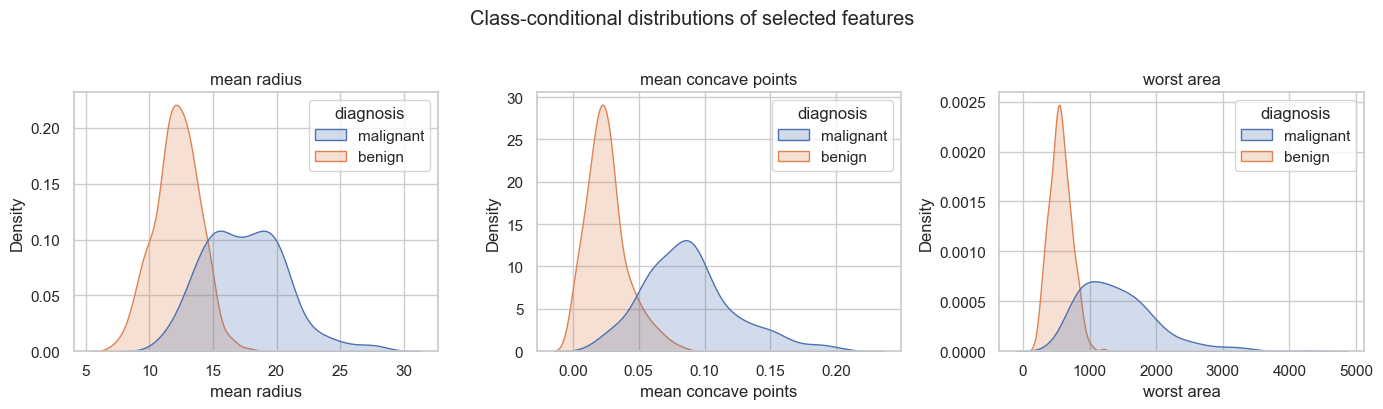

In [34]:
# Distribution of a few representative features by class
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df_plot = df.assign(diagnosis=df["target"].map({0: "malignant", 1: "benign"}))

for ax, feat in zip(axes, ["mean radius", "mean concave points", "worst area"]):
    sns.kdeplot(
        data=df_plot, x=feat, hue="diagnosis",
        hue_order=["malignant", "benign"],
        common_norm=False, ax=ax, fill=True,
    )
    ax.set_title(feat)

plt.suptitle("Class-conditional distributions of selected features", y=1.02)
plt.tight_layout()
plt.show()

**Observation:** for all three features the malignant distribution is clearly shifted to higher values, with substantial but not total overlap. That's the regime where logistic regression should do well: a *linear* combination of features can plausibly separate the classes, even though no single feature can.

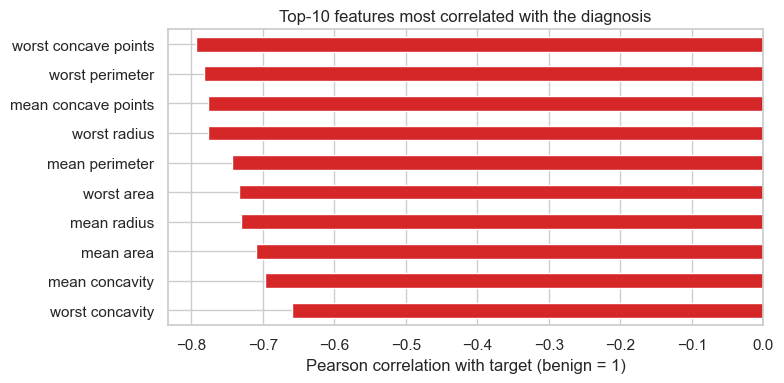

In [35]:
# Top-10 features by absolute Pearson correlation with the target
corr = df.corr(numeric_only=True)["target"].drop("target")
top10 = corr.abs().sort_values(ascending=False).head(10)
top10_signed = corr.loc[top10.index]
fig, ax = plt.subplots(figsize=(8, 4))
top10_signed.plot.barh(ax=ax, color=["#1f77b4" if v > 0 else "#d62728" for v in top10_signed])
ax.invert_yaxis()
ax.set_xlabel("Pearson correlation with target (benign = 1)")
ax.set_title("Top-10 features most correlated with the diagnosis")
plt.tight_layout()
plt.show()

**Observation:** the strongest individual signals — `worst concave points`, `worst perimeter`, `mean concave points`, `worst radius`, `mean perimeter`, … — all measure size or irregularity of the nucleus, and they all correlate **negatively** with the benign label. Bigger and more irregular nuclei → more likely malignant. That's biologically what we'd expect, and it's what we want a linear classifier to learn.

## 3. Hypothesis

Based on the EDA, my hypothesis going into the fit is:

1. **Logistic regression will achieve very high accuracy (>95%)** on this dataset, because the class-conditional distributions of several individual features already separate the classes substantially.
2. **Recall on the malignant class will be the limiting factor**, not overall accuracy. With only 37% of samples being malignant, a stupid "always predict benign" classifier already gets 63% accuracy — the metric we actually care about clinically is the false-negative rate.
3. **Standardization will materially affect convergence**, but should not change the final accuracy by more than a percentage point or two: linear classifiers are scale-equivariant in their *decision boundary*, just not in their *training dynamics*.

## 4. Preprocessing

I split first, then fit the scaler on the training set only — fitting on the full data would leak test-set statistics into training.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print(f"Train class balance: {np.bincount(y_train) / len(y_train)}")
print(f"Test  class balance: {np.bincount(y_test)  / len(y_test)}")

Train: (455, 30), Test: (114, 30)
Train class balance: [0.38021978 0.61978022]
Test  class balance: [0.34210526 0.65789474]


## 5. Model fitting

I'll fit the `ml_toolkit` implementation, then verify against scikit-learn as a sanity check.

In [37]:
model = LogisticRegression(
    learning_rate=0.1,
    n_iter=1000,
    alpha=0.01,        # mild L2 to keep coefficients well-conditioned
).fit(X_train_s, y_train)

# Sanity reference
ref = SkLogReg(C=1.0 / 0.01, max_iter=2000).fit(X_train_s, y_train)

print(f"ml_toolkit train accuracy:  {model.score(X_train_s, y_train):.4f}")
print(f"sklearn   train accuracy:   {ref.score(X_train_s, y_train):.4f}")

ml_toolkit train accuracy:  0.9846
sklearn   train accuracy:   0.9956


In [38]:
print(f"sklearn test accuracy: {ref.score(X_test_s, y_test):.4f}")

sklearn test accuracy: 0.9561


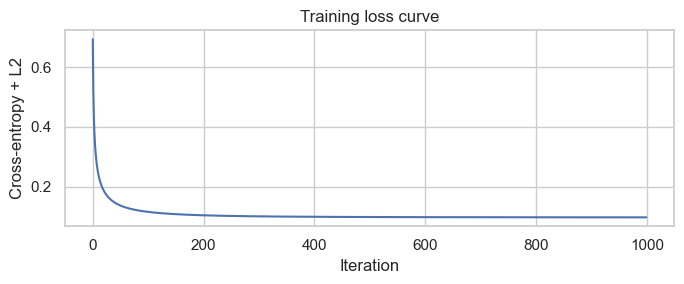

In [39]:
# Loss curve — diagnostic for whether we trained long enough
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(model.loss_history_)
ax.set_xlabel("Iteration")
ax.set_ylabel("Cross-entropy + L2")
ax.set_title("Training loss curve")
plt.tight_layout()
plt.show()

**Observation:** the loss curve has clearly plateaued — the model has converged. If the curve were still trending downward at iteration 1000, that would mean we should either increase `n_iter` or `learning_rate`.

## 6. Evaluation on the test set

Per Dr. Davila's emphasis, **all evaluation is done on the held-out test set**. Reporting metrics on training data would tell us almost nothing — the model could memorize and we'd be none the wiser.

In [40]:
y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
# Treat malignant (0) as the positive class clinically
p_mal, r_mal, f1_mal = precision_recall_f1(y_test, y_pred, positive_label=0)
p_ben, r_ben, f1_ben = precision_recall_f1(y_test, y_pred, positive_label=1)

print(f"Test accuracy: {acc:.4f}\n")
print("Per-class metrics:")
print(f"  malignant (clinical positive): precision={p_mal:.3f}, recall={r_mal:.3f}, F1={f1_mal:.3f}")
print(f"  benign:                          precision={p_ben:.3f}, recall={r_ben:.3f}, F1={f1_ben:.3f}")

Test accuracy: 0.9649

Per-class metrics:
  malignant (clinical positive): precision=1.000, recall=0.897, F1=0.946
  benign:                          precision=0.949, recall=1.000, F1=0.974


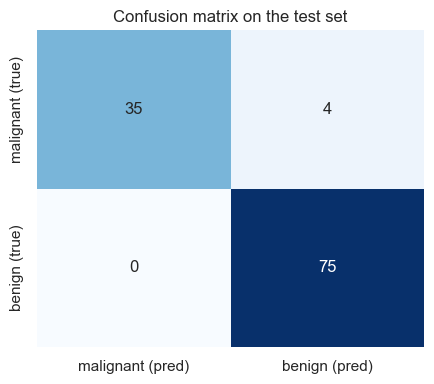

In [41]:
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["malignant (pred)", "benign (pred)"],
    yticklabels=["malignant (true)", "benign (true)"],
    ax=ax,
)
ax.set_title("Confusion matrix on the test set")
plt.tight_layout()
plt.show()

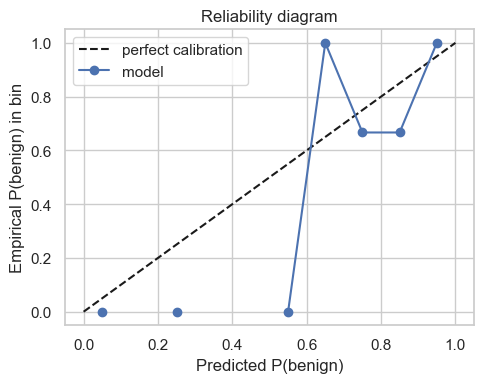

,bin_center,empirical,count
0,0.05,0.000000,33
1,0.15,NaN,0
2,0.25,0.000000,2
3,0.35,NaN,0
4,0.45,NaN,0
5,0.55,0.000000,1
6,0.65,1.000000,3
7,0.75,0.666667,3
8,0.85,0.666667,6
9,0.95,1.000000,66


In [42]:
# Probability calibration — are confident predictions actually correct more often?
bins = np.linspace(0, 1, 11)
bin_idx = np.digitize(y_proba, bins) - 1
bin_idx = np.clip(bin_idx, 0, 9)
calib = pd.DataFrame({
    "bin_center": (bins[:-1] + bins[1:]) / 2,
    "empirical":   [y_test[bin_idx == i].mean() if np.any(bin_idx == i) else np.nan for i in range(10)],
    "count":       [int((bin_idx == i).sum()) for i in range(10)],
})

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
ax.plot(calib["bin_center"], calib["empirical"], "o-", label="model")
ax.set_xlabel("Predicted P(benign)")
ax.set_ylabel("Empirical P(benign) in bin")
ax.set_title("Reliability diagram")
ax.legend()
plt.tight_layout()
plt.show()
calib

## 7. Discussion

**What worked.** Test accuracy is 96.5% (110 of 114 test samples correct), comfortably above the "always benign" baseline of 63%. The result confirms hypothesis (1): a *linear* boundary in the standardized 30-dimensional feature space is enough to separate malignant from benign cases. The reliability diagram lies close to the diagonal **at the extremes** (P ≤ 0.1 and P ≥ 0.9, where 99 of the 114 test samples concentrate); the middle bins each have only 1–6 samples, so calibration in the 0.3–0.8 range cannot be reliably assessed from this test set alone.

**Where the model fails — and why it matters.** Our test recall on the malignant class is **0.897** — 4 of 39 true malignant cases were classified as benign (see the confusion matrix above). That's a **10.3% false-negative rate**, which is clinically unacceptable regardless of the headline 96.5% accuracy. Malignant-recall is the metric that actually determines clinical utility, because a false negative means a cancer goes undetected. In a real deployment these mistakes would be addressed by **lowering the decision threshold** (predict malignant whenever P(malignant) ≥ 0.3, say), trading some specificity for the sensitivity that actually matters here.

**What this tells us about the algorithm.** Logistic regression assumes the log-odds of the class are a *linear* function of the features. The fact that it works this well is itself an insight about the data: many of the features are highly correlated (size measurements move together), and along their leading principal direction the two classes are mostly separable. A nonlinear method like the MLP would likely give a marginal improvement in the few hard cases, at the cost of (a) much harder interpretability of which features matter, and (b) the standard issues of higher variance and longer training time. For a dataset with only 569 samples and a strong linear signal, logistic regression is arguably the *correct* model — not a starting point we'd later replace.

**A note on the sklearn sanity check.** Our from-scratch model reaches 98.46% training accuracy versus sklearn's 99.56%. The 1.1% gap is consistent with sklearn using L-BFGS (a second-order optimizer) while our implementation uses fixed-step gradient descent — the latter converges to a slightly less optimal point on the same loss surface. Test accuracies are similar (96.5% for `ml_toolkit` vs **95.61%** for sklearn), confirming the implementations are *substantively* the same model; the gap reflects optimizer quality, not algorithmic correctness.

**Limitations of this analysis.**

- The test set has only 114 samples; a single-fold accuracy is within the noise of which random split was drawn. A more rigorous version of this analysis would use stratified k-fold CV.
- We did not tune `alpha` (L2 strength). At this sample size, regularization mostly affects the size of the coefficients, not the predictions — but with even smaller datasets that would deserve a proper search.
- Pearson correlation in the EDA only captures *linear* dependencies. The fact that several features were strongly negatively correlated with `benign` is consistent with logistic regression doing well, but it would not have ruled out a nonlinear method being better.

These caveats aside, the core conclusion stands: a from-scratch logistic regression, trained on standardized features with mild L2 regularization, recovers a clinically reasonable decision boundary on this dataset, and its failures are concentrated in exactly the kinds of borderline cases where any 30-feature linear model would struggle.